In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# getting the values from the dataeset
df = pd.read_csv("/content/drive/MyDrive/SDGP/ML/Dataset - Long beans.csv", encoding="utf-8")

In [ ]:
# printing the first 5 values
df.head()

,Year,Month,Producer Price Rs/kg,Wholesale Price Rs/kg,Retail Price Rs/kg,Month on CCIP change,Month on CCIP (Core) change,Inflation rate CCIP on Food monthly (Base Value 17044.70),Inflation rate CCIP on Non-Food monthly (Base Value 43320.04),Inflation rate NCIP on Food monthly (Base Value 14156.29),Inflation rate NCIP on Non-Food monthly (Base Value 17986.41),Inflation rate NCIP on All Items monthly (Base Value32142.69),Minimum Temperature,Maximum Temperature,Colombo Rainfall mm,Galle Rainfall mm,Hambantota Rainfall mm
0,2014,January,22.37,29.99,93.59,0%,0%,0.4%,5.7%,0.3%,5.2%,3.1%,23.6,31.4,85.6,61.0,2.4
1,2014,February,28.77,30.29,91.75,0%,0%,-0.2%,0.1%,-0.5%,0.3%,-0.1%,23.6,31.6,19.5,42.9,0.0
2,2014,March,29.89,27.78,88.47,0%,0.3%,-0.3%,0.1%,0.3%,0.1%,0.2%,24.8,32.3,144.8,68.0,97.6
3,2014,April,33.26,36.83,85.06,0.2%,0.1%,0.8%,0%,1.7%,0.3%,0.9%,25.3,32.2,254.7,158.7,13.6
4,2014,May,48.12,62.59,119.51,0.4%,0%,1.5%,-0.1%,1.9%,0%,0.8%,26.6,31.6,83.5,185.1,76.1


In [ ]:
# renaming columns for easy progression
df.rename(columns={
    'Year': 'year',
    'Month': 'month',
    'Producer Price Rs/kg': 'producer_price',
    'Wholesale Price Rs/kg': 'wholesale_price',
    'Retail Price Rs/kg': 'retail_price',
    'Month on CCIP change': 'month_ccip_change',
    'Month on CCIP (Core) change': 'month_ccip_core_change',
    'Inflation rate CCIP on Food monthly (Base Value 17044.70)': 'inflation_ccip_food',
    'Inflation rate CCIP on Non-Food monthly (Base Value 43320.04)': 'inflation_ccip_non_food',
    'Inflation rate NCIP on Food monthly (Base Value 14156.29)': 'inflation_ncip_food',
    'Inflation rate NCIP on Non-Food monthly (Base Value 17986.41)': 'inflation_ncip_non_food',
    'Inflation rate NCIP on All Items monthly (Base Value32142.69)': 'inflation_ncip_all_items',
    'Minimum Temperature': 'min_temperature',
    'Maximum Temperature': 'max_temperature',
    'Colombo Rainfall mm': 'colombo_rainfall_mm',
    'Galle Rainfall mm': 'galle_rainfall_mm',
    'Hambantota Rainfall mm': 'hambantota_rainfall_mm',
}, inplace=True)
df.head()

,year,month,producer_price,wholesale_price,retail_price,month_ccip_change,month_ccip_core_change,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,min_temperature,max_temperature,colombo_rainfall_mm,galle_rainfall_mm,hambantota_rainfall_mm
0,2014,January,22.37,29.99,93.59,0%,0%,0.4%,5.7%,0.3%,5.2%,3.1%,23.6,31.4,85.6,61.0,2.4
1,2014,February,28.77,30.29,91.75,0%,0%,-0.2%,0.1%,-0.5%,0.3%,-0.1%,23.6,31.6,19.5,42.9,0.0
2,2014,March,29.89,27.78,88.47,0%,0.3%,-0.3%,0.1%,0.3%,0.1%,0.2%,24.8,32.3,144.8,68.0,97.6
3,2014,April,33.26,36.83,85.06,0.2%,0.1%,0.8%,0%,1.7%,0.3%,0.9%,25.3,32.2,254.7,158.7,13.6
4,2014,May,48.12,62.59,119.51,0.4%,0%,1.5%,-0.1%,1.9%,0%,0.8%,26.6,31.6,83.5,185.1,76.1


In [ ]:
# function for automatic calculation of usning te base value and the percentage in the columns
def calc_values_using_percentage(base_val, column_name):
  base_value = base_val
  calculated_values = [base_value]  # Start with the base value for January

  # Process the month_ccip_change to calculate the new values
  for i in range(1, len(df)):
      # Convert percentage change to numeric (e.g., "0.4%" → 0.004)
      percentage_change = float(df.loc[i, column_name].strip('%')) / 100
      # Calculate the new value based on the previous month's value
      new_value = calculated_values[-1] * (1 + percentage_change)
      calculated_values.append(new_value)

  # Update the DataFrame
  df[column_name] = calculated_values

In [ ]:
# updating the ccip values
calc_values_using_percentage(17116.88, "inflation_ccip_food")
calc_values_using_percentage(45789.28, "inflation_ccip_non_food")

df.head()

,year,month,producer_price,wholesale_price,retail_price,month_ccip_change,month_ccip_core_change,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,min_temperature,max_temperature,colombo_rainfall_mm,galle_rainfall_mm,hambantota_rainfall_mm
0,2014,January,22.37,29.99,93.59,0%,0%,17116.880000,45789.280000,0.3%,5.2%,3.1%,23.6,31.4,85.6,61.0,2.4
1,2014,February,28.77,30.29,91.75,0%,0%,17082.646240,45835.069280,-0.5%,0.3%,-0.1%,23.6,31.6,19.5,42.9,0.0
2,2014,March,29.89,27.78,88.47,0%,0.3%,17031.398301,45880.904349,0.3%,0.1%,0.2%,24.8,32.3,144.8,68.0,97.6
3,2014,April,33.26,36.83,85.06,0.2%,0.1%,17167.649488,45880.904349,1.7%,0.3%,0.9%,25.3,32.2,254.7,158.7,13.6
4,2014,May,48.12,62.59,119.51,0.4%,0%,17425.164230,45835.023445,1.9%,0%,0.8%,26.6,31.6,83.5,185.1,76.1


In [ ]:
# updating the ncip values
calc_values_using_percentage(14198.75, "inflation_ncip_food")
calc_values_using_percentage(18921.70, "inflation_ncip_non_food")
calc_values_using_percentage(33139.11, "inflation_ncip_all_items")

df.head()

,year,month,producer_price,wholesale_price,retail_price,month_ccip_change,month_ccip_core_change,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,min_temperature,max_temperature,colombo_rainfall_mm,galle_rainfall_mm,hambantota_rainfall_mm
0,2014,January,22.37,29.99,93.59,0%,0%,17116.880000,45789.280000,14198.750000,18921.700000,33139.110000,23.6,31.4,85.6,61.0,2.4
1,2014,February,28.77,30.29,91.75,0%,0%,17082.646240,45835.069280,14127.756250,18978.465100,33105.970890,23.6,31.6,19.5,42.9,0.0
2,2014,March,29.89,27.78,88.47,0%,0.3%,17031.398301,45880.904349,14170.139519,18997.443565,33172.182832,24.8,32.3,144.8,68.0,97.6
3,2014,April,33.26,36.83,85.06,0.2%,0.1%,17167.649488,45880.904349,14411.031891,19054.435896,33470.732477,25.3,32.2,254.7,158.7,13.6
4,2014,May,48.12,62.59,119.51,0.4%,0%,17425.164230,45835.023445,14684.841496,19054.435896,33738.498337,26.6,31.6,83.5,185.1,76.1


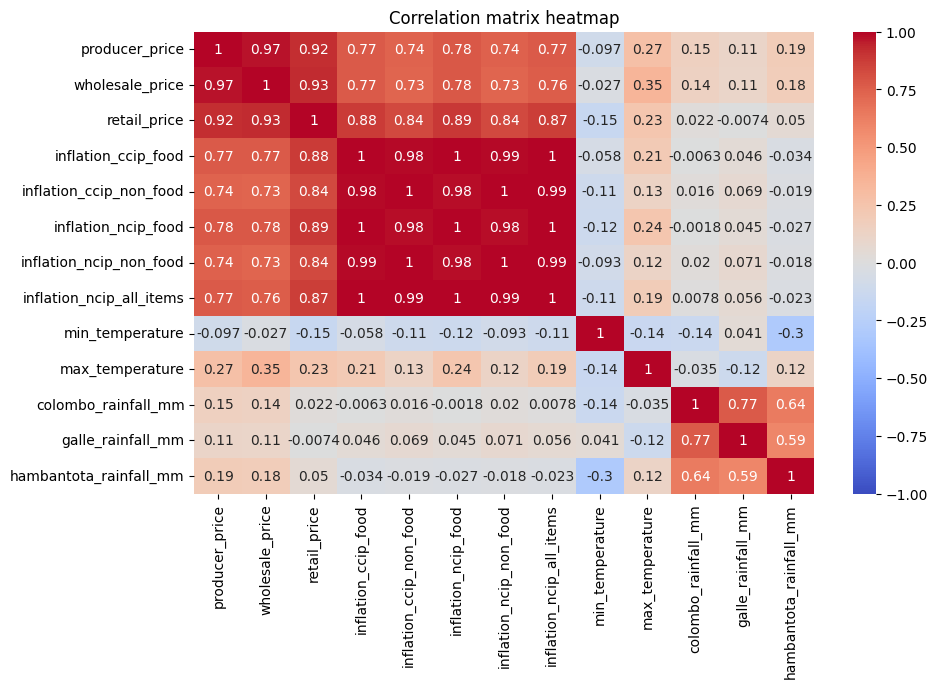

In [ ]:
numeric_columns = df.select_dtypes(include=['float64', 'float64'])
correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation matrix heatmap")
plt.show()